In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Reading and exploring data

In [3]:
data = pd.read_csv('data.csv')

In [4]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177.0,3,low,F,44,1233.0,1
1,2,F,Flight,4,5,216.0,2,low,M,59,3088.0,1
2,3,A,Flight,2,2,183.0,4,low,M,48,3374.0,1
3,4,B,Flight,3,3,176.0,4,medium,M,10,1177.0,1
4,5,C,Flight,2,2,184.0,3,medium,F,46,2484.0,1


In [5]:
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10901.000000,10999.000000,10999.000000,10860.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.194386,3.567597,13.373216,3641.667035,0.596691
std,3175.28214,1.141490,1.413603,48.063598,1.522860,16.205527,1635.078989,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1843.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4157.500000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5058.250000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7684.000000,1.000000


In [6]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177.0,3,low,F,44,1233.0,1
1,2,F,Flight,4,5,216.0,2,low,M,59,3088.0,1
2,3,A,Flight,2,2,183.0,4,low,M,48,3374.0,1
3,4,B,Flight,3,3,176.0,4,medium,M,10,1177.0,1
4,5,C,Flight,2,2,184.0,3,medium,F,46,2484.0,1


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10999 non-null  int64  
 1   Warehouse_block      10999 non-null  object 
 2   Mode_of_Shipment     10999 non-null  object 
 3   Customer_care_calls  10999 non-null  int64  
 4   Customer_rating      10999 non-null  int64  
 5   Cost_of_the_Product  10901 non-null  float64
 6   Prior_purchases      10999 non-null  int64  
 7   Product_importance   10845 non-null  object 
 8   Gender               10999 non-null  object 
 9   Discount_offered     10999 non-null  int64  
 10  Weight_in_gms        10860 non-null  float64
 11  Reached.on.Time_Y.N  10999 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.0+ MB


Visualizing Data

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
categorical_variables = list()
numerical_variables = list()

Warehouse_block: ['D' 'F' 'A' 'B' 'C']


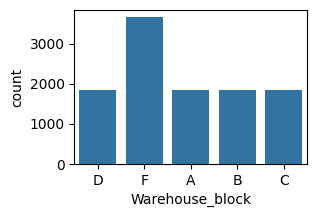

In [10]:
print(f"Warehouse_block: {data.Warehouse_block.unique()}")
fig = plt.figure(figsize=(3, 2))
sns.countplot(data=data, x='Warehouse_block')
plt.show()
data.Warehouse_block.value_counts() # Categorical variable
categorical_variables.append('Warehouse_block')

Mode_of_Shipment: ['Flight' 'Ship' 'Road']


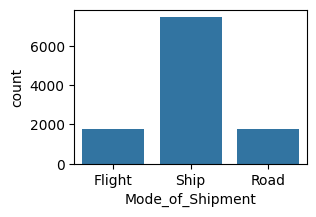

In [11]:
print(f"Mode_of_Shipment: {data.Mode_of_Shipment.unique()}")
fig = plt.figure(figsize=(3, 2))
sns.countplot(data=data, x='Mode_of_Shipment')
plt.show()
data.Mode_of_Shipment.value_counts() # Categorical variable
categorical_variables.append('Mode_of_Shipment')

Customer_care_calls: [4 2 3 5 6 7]


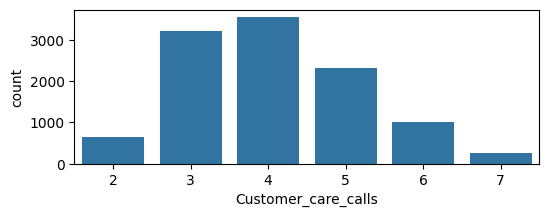

In [12]:
print(f"Customer_care_calls: {data.Customer_care_calls.unique()}")
fig = plt.figure(figsize=(6, 2))
sns.countplot(data=data, x='Customer_care_calls')
plt.show()
data.Customer_care_calls.value_counts()
categorical_variables.append('Customer_care_calls')

Customer_rating: [2 5 3 1 4]


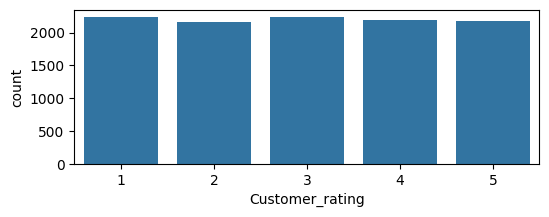

In [13]:
print(f"Customer_rating: {data.Customer_rating.unique()}")
fig = plt.figure(figsize=(6, 2))
sns.countplot(data=data, x='Customer_rating')
plt.show()
data.Customer_rating.value_counts()
categorical_variables.append('Customer_rating')

In [14]:
data.Cost_of_the_Product.isna().sum()

98

In [15]:
avg_cost = data.Cost_of_the_Product.mean()
median_cost = data.Cost_of_the_Product.median()
q1 = data.Cost_of_the_Product.quantile(0.25)
q3 = data.Cost_of_the_Product.quantile(0.75)
iqr = q3 - q1
lower_bound = q1-(1.5*iqr)
upper_bound = q3+(1.5*iqr)
# Skewness
distance_to_q1 = median_cost - q1
distance_to_q3 = q3 - median_cost
print('Skewnes: ', "Right skewed" if distance_to_q3 > distance_to_q1 else "Left Skewed" if distance_to_q3 < distance_to_q1 else "Normal")

Skewnes:  Left Skewed


In [16]:
data.Cost_of_the_Product.fillna(median_cost, inplace=True)

Cost_of_the_Product: [177. 216. 183. 176. 184. 162. 250. 233. 150. 164. 189. 232. 198. 275.
 152. 227. 143. 239. 145. 161. 156. 211. 251. 225. 172. 214. 223. 234.
 149. 137. 181. 215. 269. 139. 174. 151. 210. 169. 160. 190. 141. 165.
 170. 203. 246. 238. 193. 221. 179. 105. 261. 202. 109. 158. 231. 206.
 187. 230. 266. 113. 257. 180. 132. 286. 175. 219. 213. 235. 271. 144.
 218. 263. 168. 265. 205. 252. 222. 220. 147. 200. 224. 247. 280. 157.
 207. 237. 264. 248. 191. 146. 135.  98.  97. 114. 112. 274. 166. 185.
 148. 270. 192. 116. 255. 209. 134. 130. 133. 140. 136. 142. 154. 155.
 127. 129. 242. 159. 294. 226. 258. 241. 208. 182. 229. 115. 212. 171.
 249. 243. 163. 272. 138. 273. 279. 173. 197. 194. 260. 186. 188. 267.
 131. 122. 103. 262. 201. 199. 167. 259. 178. 123. 217. 124.  96. 244.
 254. 128. 204. 245. 228. 268. 236. 108. 276. 281. 253. 104. 240. 121.
 153. 111. 117. 195. 110. 278. 119. 196. 291. 118. 283. 100. 256. 285.
 284. 101. 296. 277. 106. 282. 126. 102. 120.  99. 125. 

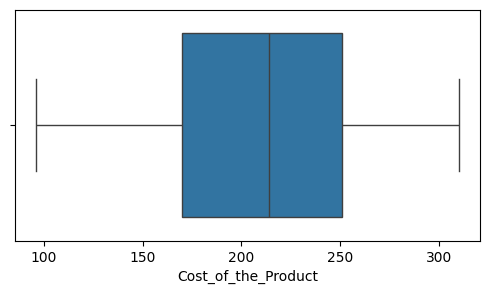

Cost_of_the_Product
214.0    151
245.0    109
257.0    107
260.0    106
254.0    101
        ... 
96.0       5
120.0      5
99.0       5
107.0      5
122.0      4
Name: count, Length: 215, dtype: int64

In [17]:
print(f"Cost_of_the_Product: {data.Cost_of_the_Product.unique()}-{len(data.Cost_of_the_Product.unique())}")
fig = plt.figure(figsize=(6, 3))
sns.boxplot(data=data, x='Cost_of_the_Product')
plt.show()
#
numerical_variables.append('Cost_of_the_Product')
data.Cost_of_the_Product.value_counts()

Prior_purchases: [ 3  2  4  6  5  7 10  8]


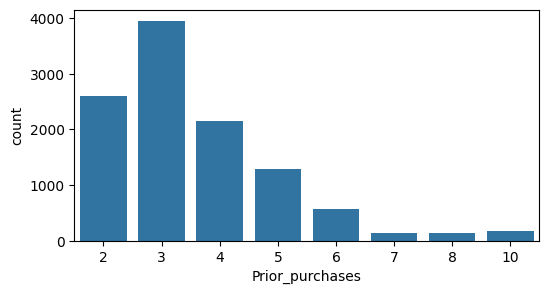

Prior_purchases
3     3955
2     2599
4     2155
5     1287
6      561
10     178
7      136
8      128
Name: count, dtype: int64

In [18]:
print(f"Prior_purchases: {data.Prior_purchases.unique()}")
fig = plt.figure(figsize=(6, 3))
sns.countplot(data=data, x='Prior_purchases')
plt.show()
categorical_variables.append('Prior_purchases')
data.Prior_purchases.value_counts()

In [19]:
print(f"Missing values: {data.Product_importance.isna().sum()}")
data.Product_importance.fillna(data.Product_importance.mode().values[0], inplace=True)

Missing values: 154


Product_importance: ['low' 'medium' 'high']


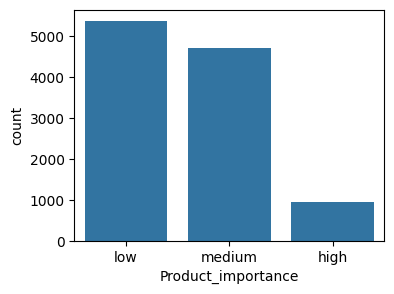

Product_importance
low       5371
medium    4698
high       930
Name: count, dtype: int64

In [20]:
print(f"Product_importance: {data.Product_importance.unique()}")
fig = plt.figure(figsize=(4, 3))
sns.countplot(data=data, x='Product_importance')
plt.show()
categorical_variables.append('Product_importance')
data.Product_importance.value_counts()

Gender: ['F' 'M']


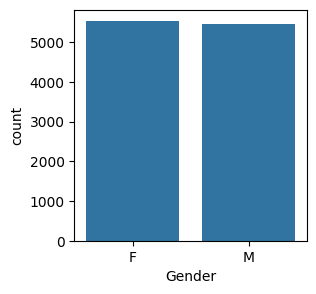

Gender
F    5545
M    5454
Name: count, dtype: int64

In [21]:
print(f"Gender: {data.Gender.unique()}")
fig = plt.figure(figsize=(3, 3))
sns.countplot(data=data, x='Gender')
plt.show()
categorical_variables.append('Gender')
data.Gender.value_counts()

Discount_offered: [44 59 48 10 46 12  3 11 29 32  1 43 45  6 36 18 38 51  2 28 24 31 61 22
  4 62 16 56 15  9 40 37 41 17 64 52 49 39 14 33 21 13 23 26 57  7 35  8
  5 53 55 47 65 25 50 60 20 19 63 58 34 54 27 42 30]


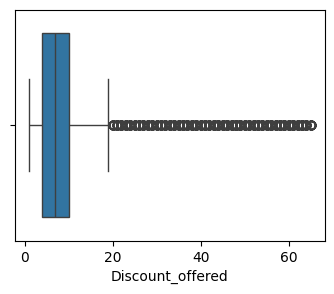

In [22]:
print(f"Discount_offered: {data.Discount_offered.unique()}")
fig = plt.figure(figsize=(4, 3))
sns.boxplot(data=data, x='Discount_offered')
plt.show()
data.Discount_offered.value_counts()
numerical_variables.append('Discount_offered')

In [23]:
print(f"Missing values: {data.Weight_in_gms.isna().sum()}")
mean_weight = data.Weight_in_gms.mean()
median_weight = data.Weight_in_gms.median()
q1 = data.Weight_in_gms.quantile(0.25)
q3 = data.Weight_in_gms.quantile(0.75)
iqr = q3 - q1
distance_to_q1 = median_weight - q1
distance_to_q3 = q3 - median_weight

print('Skewnes: ', "Right skewed" if distance_to_q3 > distance_to_q1 else "Left Skewed" if distance_to_q3 < distance_to_q1 else "Normal")

Missing values: 139
Skewnes:  Left Skewed


In [24]:
data.Weight_in_gms.fillna(median_weight, inplace=True)

Weight_in_gms: [1233. 3088. 3374. ... 1086. 1649. 1098.]


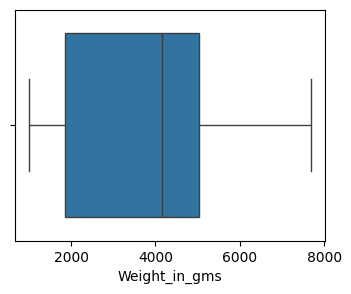

Weight_in_gms
4157.5    139
4883.0     12
1145.0     10
5672.0     10
1005.0     10
         ... 
2599.0      1
1807.0      1
3640.0      1
2860.0      1
1098.0      1
Name: count, Length: 4019, dtype: int64

In [25]:
print(f"Weight_in_gms: {data.Weight_in_gms.unique()}")
fig = plt.figure(figsize=(4, 3))
sns.boxplot(data=data, x='Weight_in_gms')
plt.show()
numerical_variables.append('Weight_in_gms')
data.Weight_in_gms.value_counts()

In [26]:
categorical_variables

['Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Prior_purchases',
 'Product_importance',
 'Gender']

In [27]:
numerical_variables

['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

In [28]:
data[categorical_variables] = data[categorical_variables].astype('category')

In [29]:
data[numerical_variables] = data[numerical_variables].astype('float')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   10999 non-null  int64   
 1   Warehouse_block      10999 non-null  category
 2   Mode_of_Shipment     10999 non-null  category
 3   Customer_care_calls  10999 non-null  category
 4   Customer_rating      10999 non-null  category
 5   Cost_of_the_Product  10999 non-null  float64 
 6   Prior_purchases      10999 non-null  category
 7   Product_importance   10999 non-null  category
 8   Gender               10999 non-null  category
 9   Discount_offered     10999 non-null  float64 
 10  Weight_in_gms        10999 non-null  float64 
 11  Reached.on.Time_Y.N  10999 non-null  int64   
dtypes: category(7), float64(3), int64(2)
memory usage: 506.3 KB
